In [1]:
# Implement Tic-Tac-Toe environment

# Game pieces:
# 0 = SPOT IS EMPTY
# 1 = SPOT IS OCCUPIED BY AGENT (X)
# -1 = SPOT IS OCCUPIED BY OPPONENT (O)

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(11)
np.random.seed(11)

class TicTacToe:
    # Initialize a new game
    def __init__self():
        self.reset()
        
    # Reset the game to starting state
    def reset(self):
        # Create empty game board (3x3 but represented as 1x9)
        self.board = [0] * 9
        self.done = False
        return tuple(self.board)
    
    # Find available actions that can be taken (empty spots)
    def available_actions(self):
        # Return all empty spots (where 0 = EMPTY)
        return [i for i in range(9) if self.board[i] == 0]

    # Applies actions
    # Returns next_state (the game board), reward, and done (whether game is over)
    def step(self, action):
        # Check if move is invalid (spot must be empty, i.e. = 0)
        if self.board[action] != 0:
            raise ValueError("Invalid move")

        # Apply agent move (agent = 1) (X)
        self.board[action] = 1

        # Check if agent wins the game
        if self.check_winner(1):
            self.done = True
            # Return board, reward (+1 since the agent won), true (game is over)
            return tuple(self.board), 1, True

        # Check for a draw after agent move
        if 0 not in self.board:
            self.done = True
            # Return board, reward (+0 due to draw), true (game is over)
            return tuple(self.board), 0, True

        # If agent didn't win and its not a draw then opponent can move:
        # Random opponent move
        opponent_action = random.choice(self.available_actions())
        # Place opponent's piece (-1) (Piece O)
        self.board[opponent_action] = -1

        # Check if opponent wins the game
        if self.check_winner(-1):
            self.done = True
            # Return board, reward (-1 since the agent lost), and true (game is over)
            return tuple(self.board), -1, True

        # Check for draw after opponent move
        if 0 not in self.board:
            self.done = True
            # Return board, reward (0 due to draw), and true (game is over)
            return tuple(self.board), 0, True

        # If game is not over yet: Return board, no current reward, and false (game isn't over)
        return tuple(self.board), 0, False

    # Check winner of the game:
    # Given the board and player_id (1 for X and -1 for O), check if player_id won the game
    def check_winner(self, player_id):
        # Win positions are in rows, columns, and diagonals
        # Numbers represent indices in the board
        win_positions = [
        [0,1,2], [3,4,5], [6,7,8],
        [0,3,6], [1,4,7], [2,5,8],
        [0,4,8], [2,4,6]]
        for position in win_positions:
            if all(self.board[i] == player_id for i in position):
                return True
        return False


In [2]:
# Q-LEARNING 

class QLearningAgent:
    def __init__(self, alpha = 0.1, gamma = 0.9, epsilon = 1.0, epsilon_decay = 0.995, epsilon_min = 0.05):
        # Initialize the Q-Table
        self.q_table = {}
        # Initializing alpha (learning rate), gamma (discount factor), epsilon (exploration-exploitation trade-off)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
    # Initialize state in the Q-table
    def initialize_state(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(9)
            
    # Choose the action in Q-Learning, either greedy or random action
    def choose_action(self, state, valid_actions):
        self.initialize_state(state)
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        
        q_values = self.q_table[state]
        
        return max(valid_actions, key=lambda action: q_values[action])
    
    # Q-Learning update
    def update(self, state, action, reward, next_state, done, valid_next_actions):
        self.initialize_state(state)
        self.initialize_state(next_state)
        current_q = self.q_table[state][action]
        
        # If game ended, target is simply the final reward
        if done:
            target = reward
        # If game isn't over, target uses the Bellman equation
        else:
            max_next_q = max(self.q_table[next_state][a] for a in valid_next_actions)
            target = reward + (self.gamma * max_next_q)
        
        # Use Q-Learning formula for update in the Q-table
        self.q_table[state][action] = self.q_table[state][action] + (self.alpha*(target - current_q))
        
    # Decay epsilon 
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [3]:
# Q-Learning training

env = TicTacToe()
agent = QLearningAgent()

episodes = 1000

reward_history = []

for i in range(episodes):
    state = env.reset()
    done = False
    while not done:
        valid_actions = env.available_actions()
        action = agent.choose_action(state, valid_actions)
        next_state, reward, done = env.step(action)
        if not done:
            next_valid_actions = env.available_actions()
        else:
            next_valid_actions = []
        agent.update(state, action, reward, next_state, done, next_valid_actions)
        state = next_state
    
    agent.decay_epsilon()
    
    reward_history.append(reward)

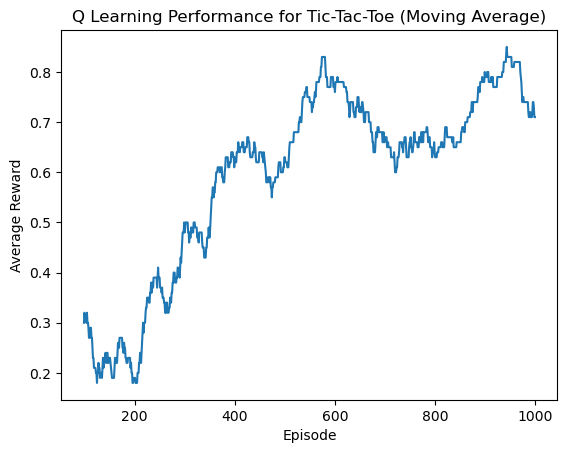

In [4]:
# Q-Learning plotting

# moving average reward as Q-Learning progresses
moving_avg = pd.Series(reward_history).rolling(100).mean()

plt.figure()
plt.plot(moving_avg)
plt.title("Q Learning Performance for Tic-Tac-Toe (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()

{'Win': 453, 'Loss': 20, 'Draw': 27}


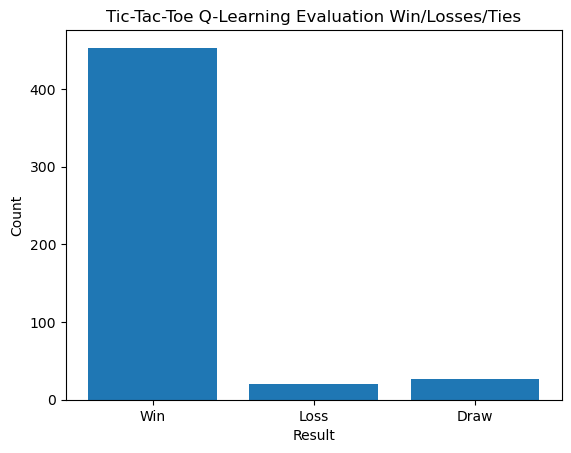

In [5]:
# Using the Q-Table after training, we evaluate performance
def evaluate_performance(agent, games):
    env = TicTacToe()
    results = {"Win": 0, "Loss": 0, "Draw": 0}
    for i in range(games):
        state = env.reset()
        done = False
        while not done:
            actions = env.available_actions()
            action = agent.choose_action(state, actions)
            state, reward, done = env.step(action)
        
        # Tally rewards when game ends
        if reward == 1:
            results["Win"] += 1
        elif reward == -1:
            results["Loss"] += 1
        elif reward == 0:
            results["Draw"] +=1
            
    return results

# Print numerical results
results = evaluate_performance(agent, 500)
print(results)

# Plot

labels = list(results.keys())
values = list(results.values())

plt.figure()
plt.bar(labels, values)
plt.title("Tic-Tac-Toe Q-Learning Evaluation Win/Losses/Ties")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()


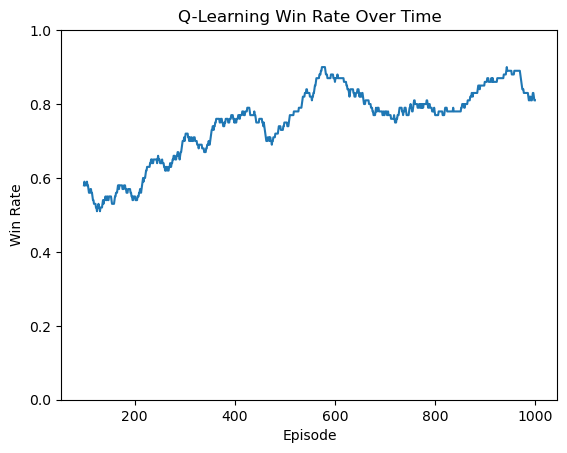

In [6]:
win_history_binary = [1 if reward == 1 else 0 for reward in reward_history]

# moving average win rate
win_rate = pd.Series(win_history_binary).rolling(100).mean()

plt.figure()
plt.plot(win_rate)
plt.title("Q-Learning Win Rate Over Time")
plt.xlabel("Episode")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()

In [7]:
# SARSA

# Updates its value using Q-value of next action actually taken
# On-Policy

class SARSA:
    def __init__(self, alpha = 0.1, gamma = 0.9, epsilon = 1.0, epsilon_decay = 0.995, epsilon_min = 0.05):
        self.q_table = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
    
    def initialize_state(self, state):
        if state not in self.q_table:
            self.q_table[state] = [0.0]*9
        
    def choose_action(self, state, valid_actions):
        self.initialize_state(state)
        
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        
        q_values = self.q_table[state]
        return max(valid_actions, key = lambda action: q_values[action])
    
    def update(self, state, action, reward, next_state, next_action, done):
        self.initialize_state(state)
        self.initialize_state(next_state)
        
        current_q = self.q_table[state][action]
        
        if done:
            target = reward
        else:
            # Key difference in SARSA is here: take next actual q
            next_q = self.q_table[next_state][next_action]
            target = reward + (self.gamma * next_q)
            
        self.q_table[state][action] = current_q + self.alpha*(target - current_q)
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, (self.epsilon * self.epsilon_decay))
        
    

In [8]:
# SARSA training

env = TicTacToe()
agent = SARSA()

episodes = 500
reward_history = []

for i in range(episodes):
    state = env.reset()
    done = False
    
    actions = env.available_actions()
    action = agent.choose_action(state, actions)
    
    while not done:
        next_state, reward, done = env.step(action)
        # different from Q-Learning: choose the actual next action
        if not done:
            next_actions = env.available_actions()
            next_action = agent.choose_action(next_state, next_actions)
        else:
            next_action = None
        # Use actual next action in the update for SARSA
        agent.update(state, action, reward, next_state, next_action, done)
        
        state = next_state
        action = next_action
        
    agent.decay_epsilon()
    reward_history.append(reward)

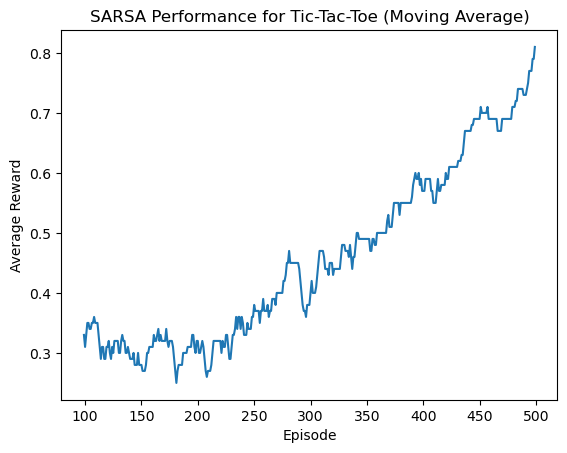

In [9]:
# SARSA plotting

# moving average reward
moving_avg = pd.Series(reward_history).rolling(100).mean()

plt.figure()
plt.plot(moving_avg)
plt.title("SARSA Performance for Tic-Tac-Toe (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()

{'Win': 419, 'Loss': 57, 'Draw': 24}


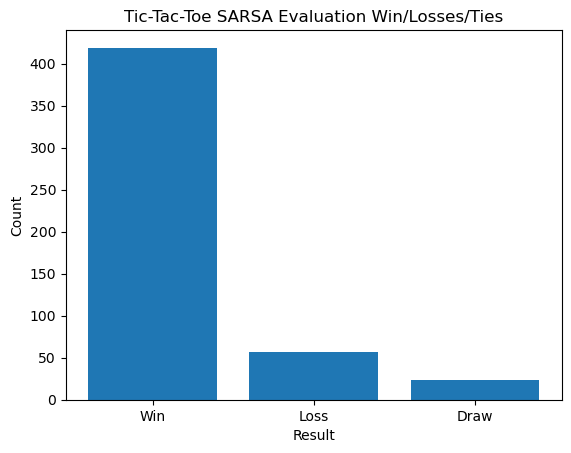

In [10]:
# using the SARSA Q-Table after training, evaluate performance
def evaluate_performance(agent, games):
    env = TicTacToe()
    results = {"Win": 0, "Loss": 0, "Draw": 0}

    for i in range(games):
        state = env.reset()
        done = False

        while not done:
            actions = env.available_actions()
            action = agent.choose_action(state, actions)
            state, reward, done = env.step(action)

        # Tally rewards when game ends
        if reward == 1:
            results["Win"] += 1
        elif reward == -1:
            results["Loss"] += 1
        else:
            results["Draw"] += 1

    return results


# Print numerical SARSA results
sarsa_results = evaluate_performance(agent, 500)
print(sarsa_results)

# Plot

labels = list(sarsa_results.keys())
values = list(sarsa_results.values())

plt.figure()
plt.bar(labels, values)
plt.title("Tic-Tac-Toe SARSA Evaluation Win/Losses/Ties")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

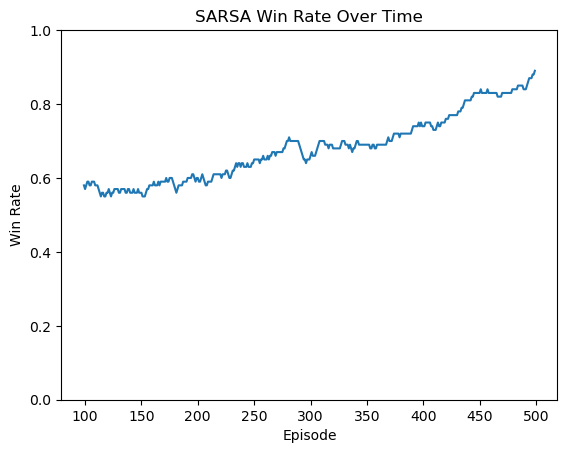

In [11]:
win_history_binary = [1 if reward == 1 else 0 for reward in reward_history]

# moving average win rate
win_rate = pd.Series(win_history_binary).rolling(100).mean()

plt.figure()
plt.plot(win_rate)
plt.title("SARSA Win Rate Over Time")
plt.xlabel("Episode")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()

In [12]:
# EXPECTED SARSA
# Expected SARSA estimates Q-Value by taking a weighted average of the Q-Values
# of all possible actions in next state

class ExpectedSARSA:
    def __init__(self, alpha = 0.1, gamma = 0.9, epsilon = 1.0, epsilon_decay = 0.995, epsilon_min = 0.05):
        
        self.q_table = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

    def initialize_state(self, state):
        if state not in self.q_table:
            self.q_table[state] = [0.0] * 9

    def choose_action(self, state, valid_actions):
        self.initialize_state(state)

        if random.random() < self.epsilon:
            return random.choice(valid_actions)

        q_values = self.q_table[state]
        return max(valid_actions, key=lambda action: q_values[action])

    def update(self, state, action, reward, next_state, done, valid_next_actions):
        self.initialize_state(state)
        self.initialize_state(next_state)

        current_q = self.q_table[state][action]

        if done:
            target = reward
        else:
            q_values = self.q_table[next_state]

            # best action under current policy
            best_action = max(valid_next_actions, key=lambda a: q_values[a])

            # expected SARSA modification
            expected_q = 0
            
            for action in valid_next_actions:
                if action == best_action:
                    prob = (1 - self.epsilon) + (self.epsilon / len(valid_next_actions))
                else:
                    prob = self.epsilon / len(valid_next_actions)

                expected_q += (prob * q_values[action])

            target = reward + (self.gamma * expected_q)

        self.q_table[state][action] = current_q + self.alpha * (target - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

In [13]:
# EXPECTED SARSA TRAINING

env = TicTacToe()
agent = ExpectedSARSA()

episodes = 500
reward_history = []

for i in range(episodes):
    state = env.reset()
    done = False

    while not done:
        actions = env.available_actions()
        action = agent.choose_action(state, actions)

        next_state, reward, done = env.step(action)

        next_actions = env.available_actions() if not done else []

        agent.update(state, action, reward, next_state, done, next_actions)

        state = next_state

    agent.decay_epsilon()
    reward_history.append(reward)

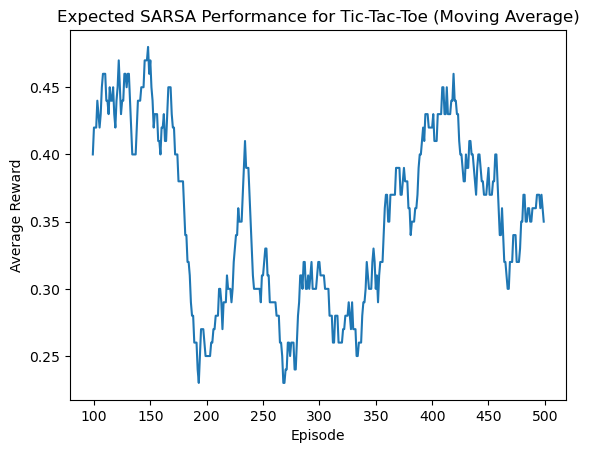

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Expected SARSA plotting

moving_avg = pd.Series(reward_history).rolling(100).mean()

plt.figure()
plt.plot(moving_avg)
plt.title("Expected SARSA Performance for Tic-Tac-Toe (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()

{'Win': 307, 'Loss': 138, 'Draw': 55}


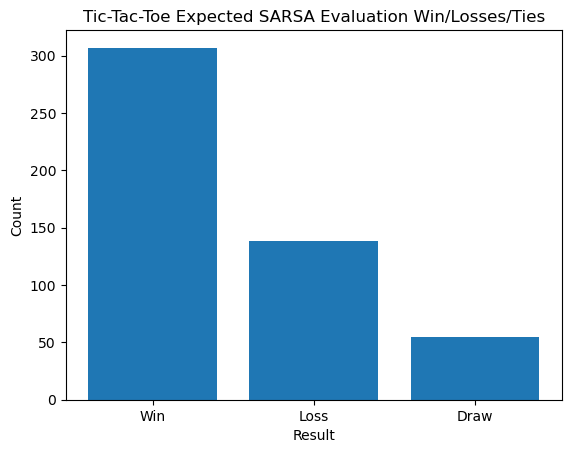

In [15]:
# using the Expected SARSA Q-Table after training, evaluate performance
def evaluate_performance(agent, games):
    env = TicTacToe()
    results = {"Win": 0, "Loss": 0, "Draw": 0}

    for i in range(games):
        state = env.reset()
        done = False

        while not done:
            actions = env.available_actions()
            action = agent.choose_action(state, actions)
            state, reward, done = env.step(action)

        # Tally rewards when game ends
        if reward == 1:
            results["Win"] += 1
        elif reward == -1:
            results["Loss"] += 1
        else:
            results["Draw"] += 1

    return results


# Print numerical Expected SARSA results
exp_sarsa_results = evaluate_performance(agent, 500)
print(exp_sarsa_results)

# Plot
labels = list(exp_sarsa_results.keys())
values = list(exp_sarsa_results.values())

plt.figure()
plt.bar(labels, values)
plt.title("Tic-Tac-Toe Expected SARSA Evaluation Win/Losses/Ties")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

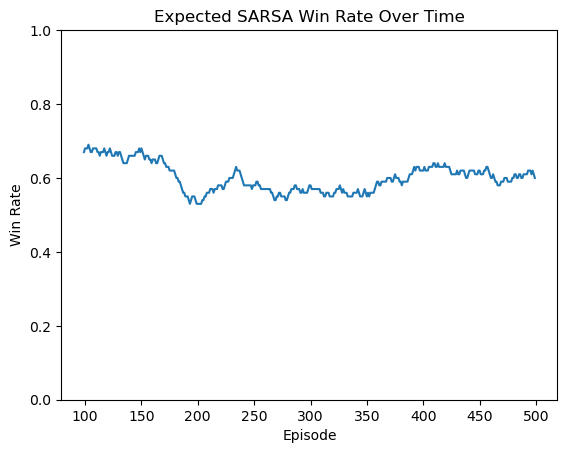

In [16]:
win_history_binary = [1 if reward == 1 else 0 for reward in reward_history]

# moving average win rate
win_rate = pd.Series(win_history_binary).rolling(100).mean()

plt.figure()
plt.plot(win_rate)
plt.title("Expected SARSA Win Rate Over Time")
plt.xlabel("Episode")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()

In [17]:
# DOUBLE Q-LEARNING
# INSTEAD OF 1 Q-TABLE, USE 2 Q-TABLES
# Using 2 Q-Tables to decouple action selection from evaluation, reducing overestimation bias

class DoubleQLearning:
    def __init__(self, alpha = 0.1, gamma = 0.9, epsilon = 1.0, epsilon_decay = 0.995, epsilon_min = 0.05):
        self.q1 = {}
        self.q2 = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
    def initialize_state(self, state):
        if state not in self.q1:
            self.q1[state] = [0.0]*9
        if state not in self.q2:
            self.q2[state] = [0.0]*9
            
    def choose_action(self, state, valid_actions):
        self.initialize_state(state)
        
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        # Double Q-Learning use sum of both tables for action selection
        combined_q = [self.q1[state][a] + self.q2[state][a] for a in range(9)]
        return max(valid_actions, key = lambda a: combined_q[a])
    
    def update(self, state, action, reward, next_state, done, valid_next_actions):
        self.initialize_state(state)
        self.initialize_state(next_state)
        
        # for double Q-Learning, randomly select a Q-Table to update (this reduces overestimation bias)
        if random.random() < 0.5:
            # choose to update Q-table 1
            current_q = self.q1[state][action]
            if done:
                target = reward
            else:
                best_action = max(valid_next_actions, key=lambda a: self.q1[next_state][a])
                target = reward + self.gamma * self.q2[next_state][best_action]
            self.q1[state][action] = current_q + self.alpha * (target - current_q)
        else:
            # choose to update Q-table 2
            current_q = self.q2[state][action]
            if done:
                target = reward
            else:
                best_action = max(valid_next_actions, key=lambda a: self.q2[next_state][a])
                target = reward + self.gamma * self.q1[next_state][best_action]
                
            self.q2[state][action] = current_q + self.alpha * (target - current_q)
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, (self.epsilon * self.epsilon_decay))
            

In [18]:
# Double Q-Learning training

env = TicTacToe()
agent = DoubleQLearning()

episodes = 500
reward_history = []

for i in range(episodes):
    state = env.reset()
    done = False

    while not done:
        actions = env.available_actions()
        action = agent.choose_action(state, actions)

        next_state, reward, done = env.step(action)

        next_actions = env.available_actions() if not done else []

        agent.update(state, action, reward, next_state, done, next_actions)

        state = next_state

    agent.decay_epsilon()
    reward_history.append(reward)

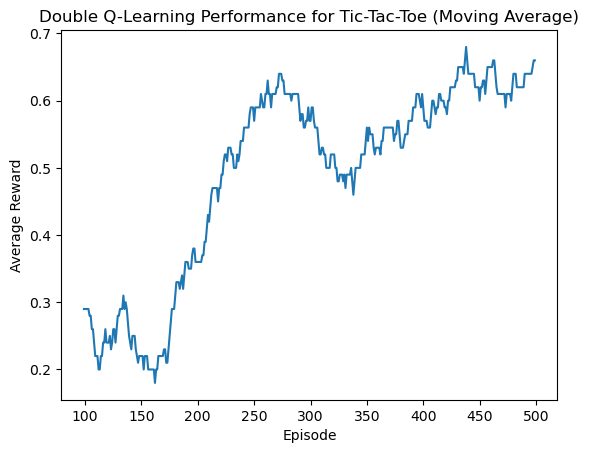

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Double Q-Learning plotting

moving_avg = pd.Series(reward_history).rolling(100).mean()

plt.figure()
plt.plot(moving_avg)
plt.title("Double Q-Learning Performance for Tic-Tac-Toe (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()

{'Win': 427, 'Loss': 54, 'Draw': 19}


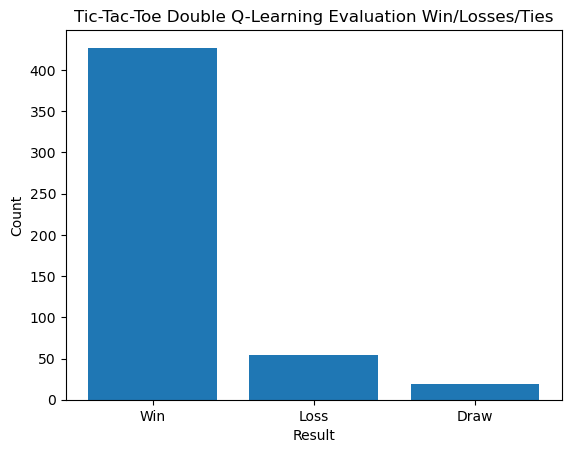

In [20]:
# using the Double Q-Learning tables after training, evaluate performance
def evaluate_performance(agent, games):
    env = TicTacToe()
    results = {"Win": 0, "Loss": 0, "Draw": 0}

    for i in range(games):
        state = env.reset()
        done = False

        while not done:
            actions = env.available_actions()
            action = agent.choose_action(state, actions)
            state, reward, done = env.step(action)

        # Tally rewards when game ends
        if reward == 1:
            results["Win"] += 1
        elif reward == -1:
            results["Loss"] += 1
        else:
            results["Draw"] += 1

    return results


# Print numerical Double Q-Learning results
double_q_results = evaluate_performance(agent, 500)
print(double_q_results)

# Plot
labels = list(double_q_results.keys())
values = list(double_q_results.values())

plt.figure()
plt.bar(labels, values)
plt.title("Tic-Tac-Toe Double Q-Learning Evaluation Win/Losses/Ties")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

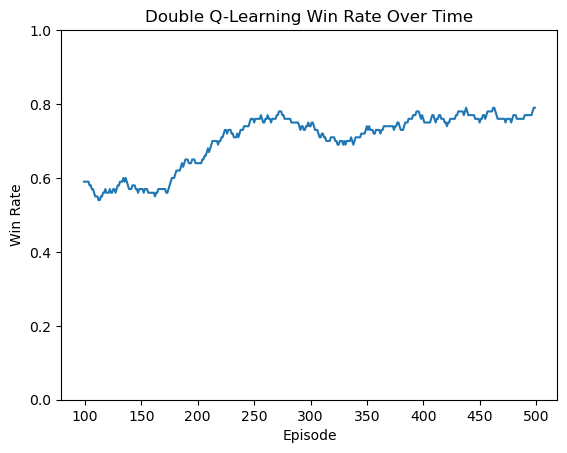

In [21]:
win_history_binary = [1 if reward == 1 else 0 for reward in reward_history]

# moving average win rate
win_rate = pd.Series(win_history_binary).rolling(100).mean()

plt.figure()
plt.plot(win_rate)
plt.title("Double Q-Learning Win Rate Over Time")
plt.xlabel("Episode")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()